### Making Figure 1

Christian Jorgensen

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

In [2]:
data_dir = "../Stelzer_Torsten/niis/"
slice_1a = nib.load(data_dir + "CT_2025-03-03_11h19_Stelzer_capsule_1a_PEG_API.nii").get_fdata()[:, :, 500:550]
slice_2 = nib.load(data_dir + "CT_2025-03-03_13h39_Stelzer_capsule_2_PEG.nii").get_fdata()[:, :, 400:450]
slice_3 = nib.load(data_dir + "CT_2025-03-03_15h35_Stelzer_capsule_4_EMPTY.nii").get_fdata()[:, :, 500:550]

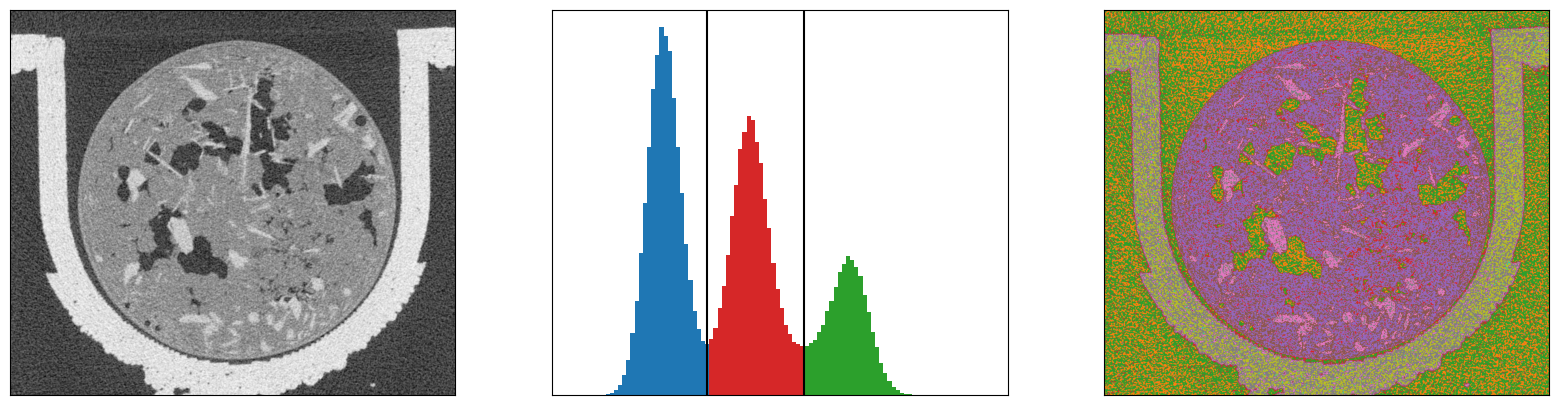

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
vlines_1 = [-455, 555]
axs[0].imshow(np.rot90(slice_1a[:, :, 0], k=3), cmap='Greys_r')

counts, bins, patches = axs[1].hist(slice_1a.flatten(), bins=100)
for patch in patches:
    bar_x = patch.get_x()
    if bar_x < vlines_1[0]:
        patch.set_facecolor('tab:blue')
    elif bar_x < vlines_1[1]:
        patch.set_facecolor('tab:red')
    else:
        patch.set_facecolor('tab:green')
        
axs[1].vlines(vlines_1, 0, 1.4e6, 'k')
axs[1].set_ylim(0, 1.4e6)

axs[2].imshow(np.rot90(slice_1a[:, :, 0], k=3), cmap='tab10')


for ax in axs:
    ax.set_yticks([])
    ax.set_xticks([])

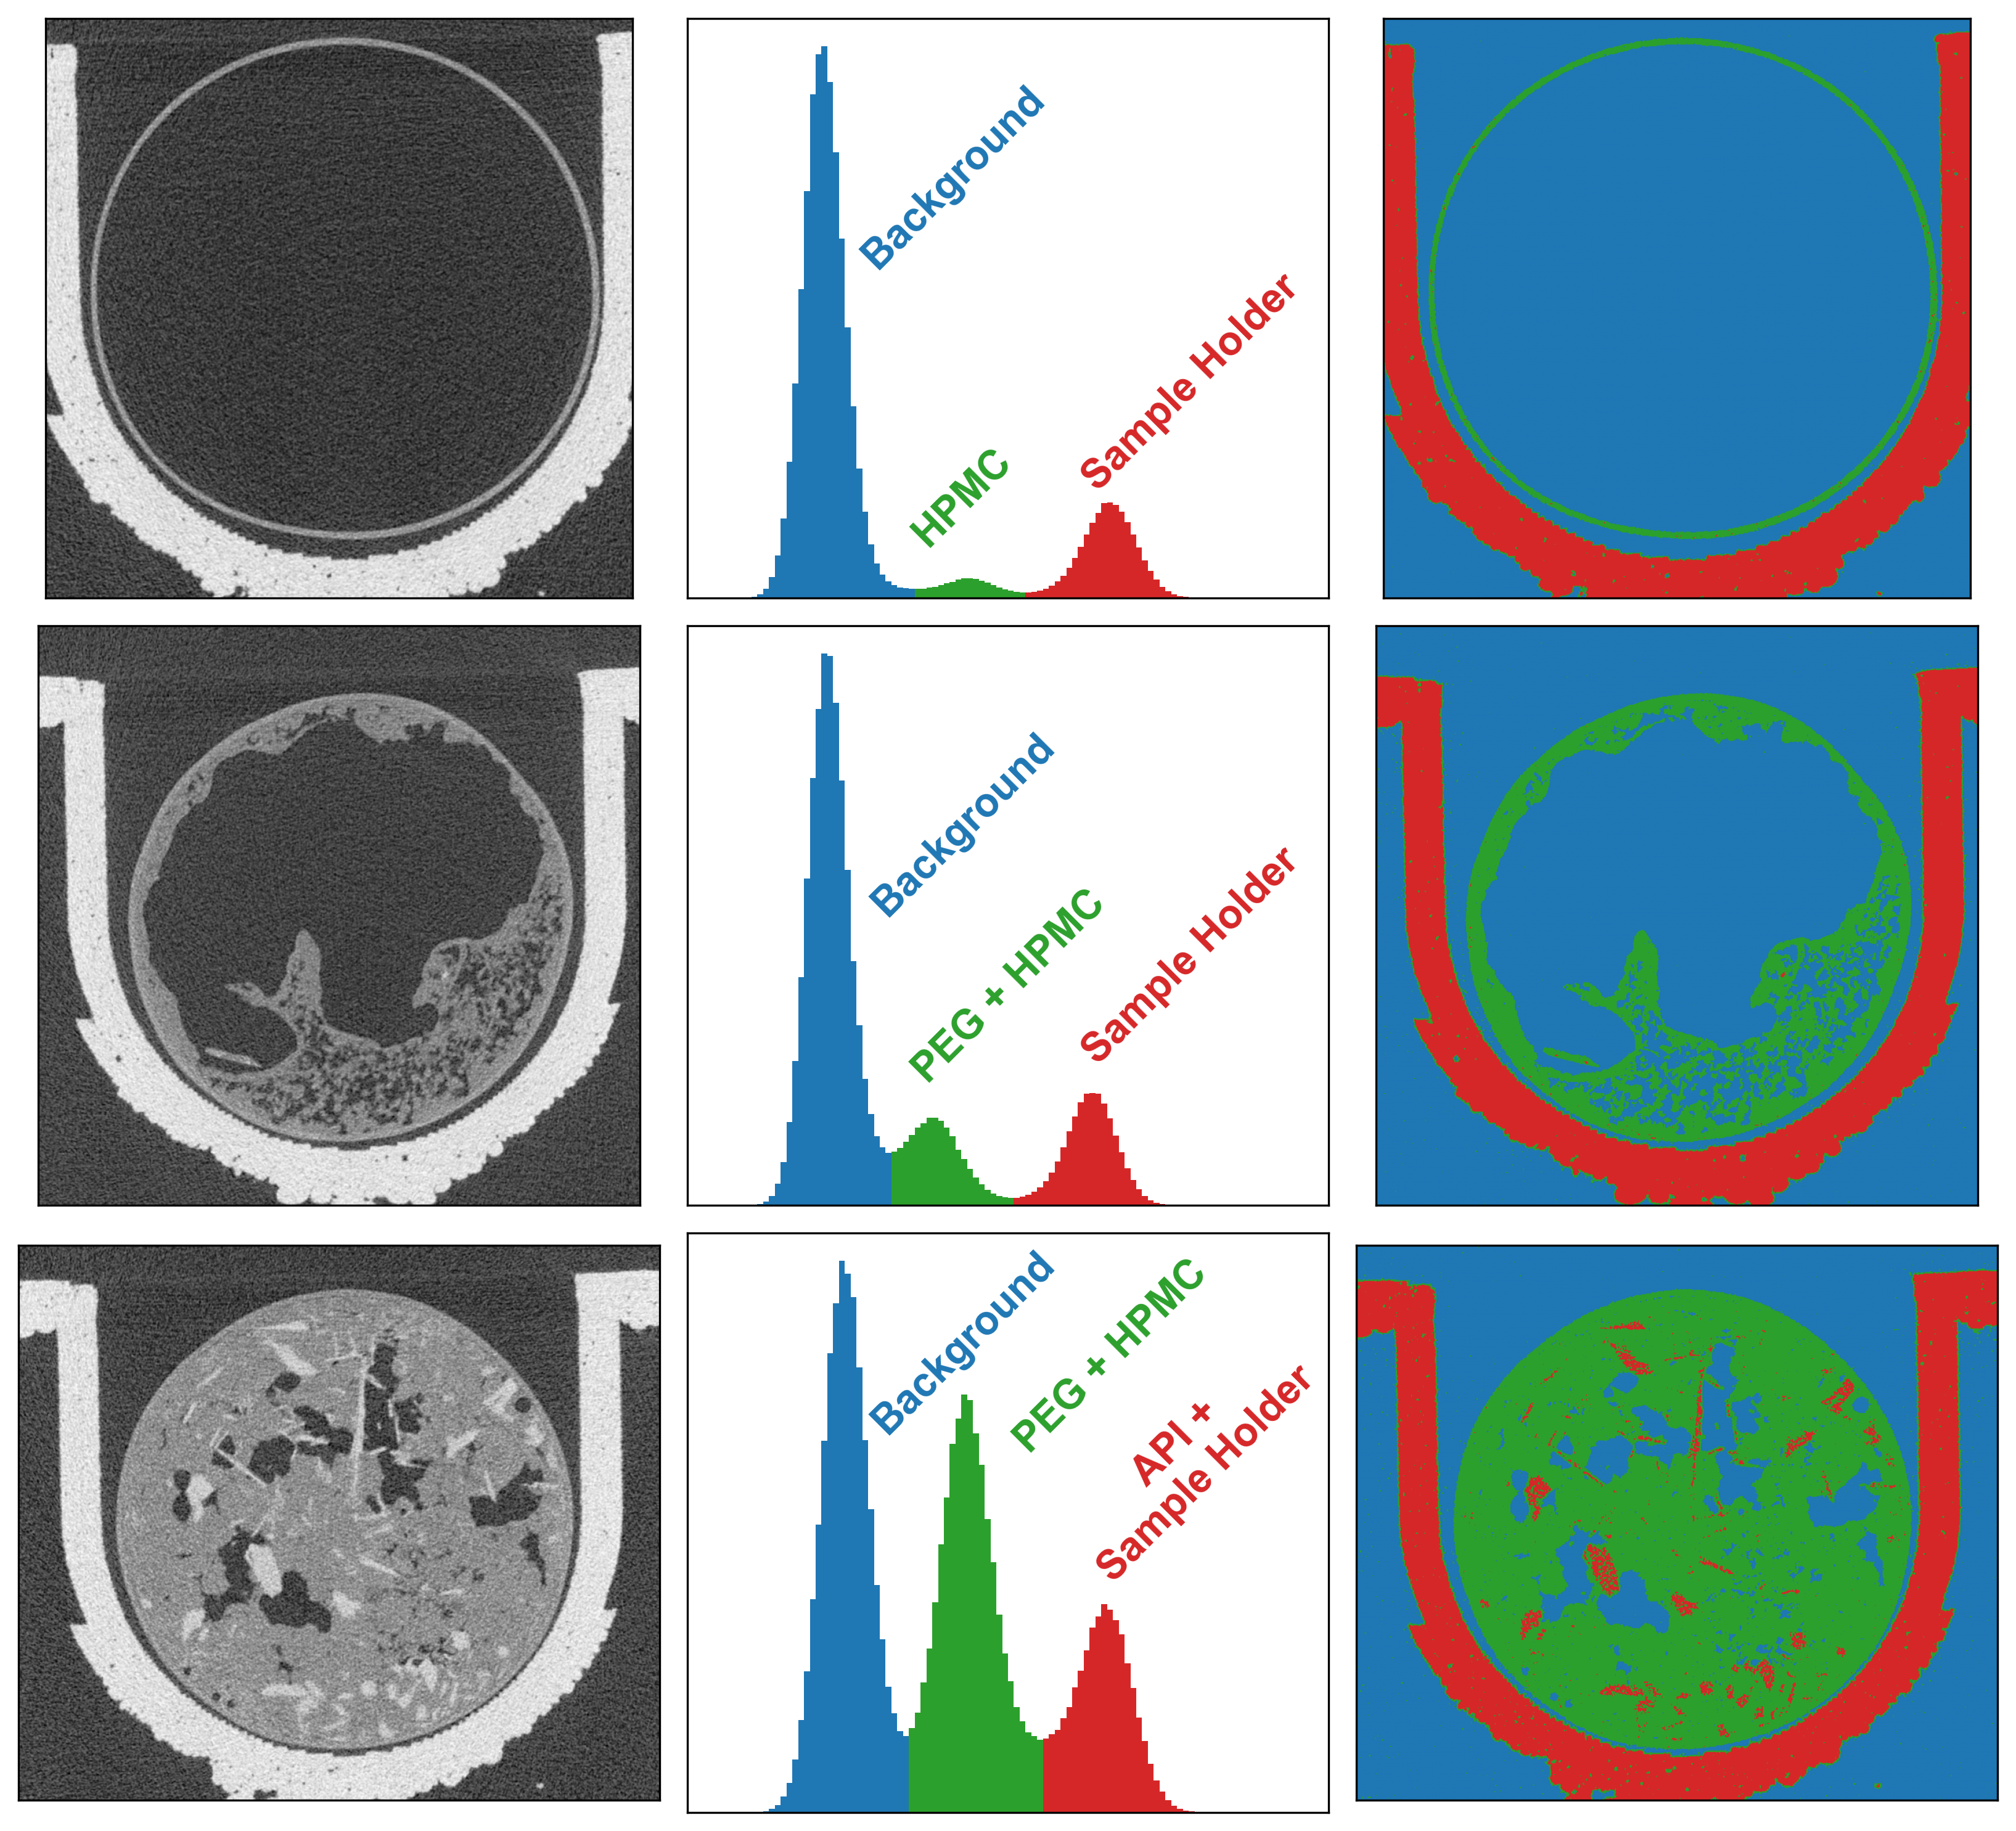

In [30]:
from matplotlib.colors import ListedColormap
fig, axs = plt.subplots(3, 3, figsize = (11, 10), dpi=300)
vlines_1 = [-455, 555]
vlines_2 = [-510, 440]
vlines_3 = [-355, 400]

cmap = ListedColormap(['tab:blue','tab:green', 'tab:red'])

for row_ax, slice, vlines in zip([axs[0, :], axs[1, :], axs[2, :]], [slice_3, slice_2, slice_1a], [vlines_3, vlines_2, vlines_1]):
    row_ax[0].imshow(np.rot90(slice[:, :, 0], k=3), cmap='Greys_r')
    
    counts, bins, patches = row_ax[1].hist(slice.flatten(), bins=100)
    for patch in patches:
        bar_x = patch.get_x()
            
        if bar_x < vlines[0]:
            patch.set_facecolor('tab:blue')
        elif bar_x < vlines[1]:
            patch.set_facecolor('tab:green')
        else:
            patch.set_facecolor('tab:red')
            
    ylim = 1.1*np.max(counts)

    # row_ax[1].vlines(vlines, 0, ylim, 'k')
    # row_ax[1].set_ylim(0, ylim)
    
    regions = np.digitize(slice[:, :, 0], bins=vlines)
    
    row_ax[2].imshow(np.rot90(regions, k=3), cmap=cmap)

for row_ax in axs:
    for ax in row_ax:
        ax.set_yticks([])
        ax.set_xticks([])

fig.text(0.425, 0.85, "Background", color='tab:blue', fontsize=16, fontweight='bold', rotation=45)
fig.text(0.43, 0.5, "Background", color='tab:blue', fontsize=16, fontweight='bold', rotation=45)
fig.text(0.43, 0.22, "Background", color='tab:blue', fontsize=16, fontweight='bold', rotation=45)

fig.text(0.45, 0.7, "HPMC", color='tab:green', fontsize=16, fontweight='bold', rotation=45)
fig.text(0.45, 0.41, "PEG + HPMC", color='tab:green', fontsize=16, fontweight='bold', rotation=45)
fig.text(0.5, 0.21, "PEG + HPMC", color='tab:green', fontsize=16, fontweight='bold', rotation=45)


fig.text(0.59, 0.73, "Sample Holder", ha='center', color='tab:red', fontsize=16, fontweight='bold', rotation=45)
fig.text(0.59, 0.42, "Sample Holder", ha='center', color='tab:red', fontsize=16, fontweight='bold', rotation=45)
fig.text(0.59, 0.14, "API +\nSample Holder", ha='center', color='tab:red', fontsize=16, fontweight='bold', rotation=45)
fig.tight_layout()
fig.savefig("imgs/1_identifying_api_peg.png")